In [7]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
import pandas as pd
from check_stationarity import load_data, load_train_data

C:\Users\giada\AppData\Local\Temp\ipykernel_23172\345917625.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  gdp_series['sasdate'] = pd.to_datetime(gdp_series['sasdate'], errors='coerce')


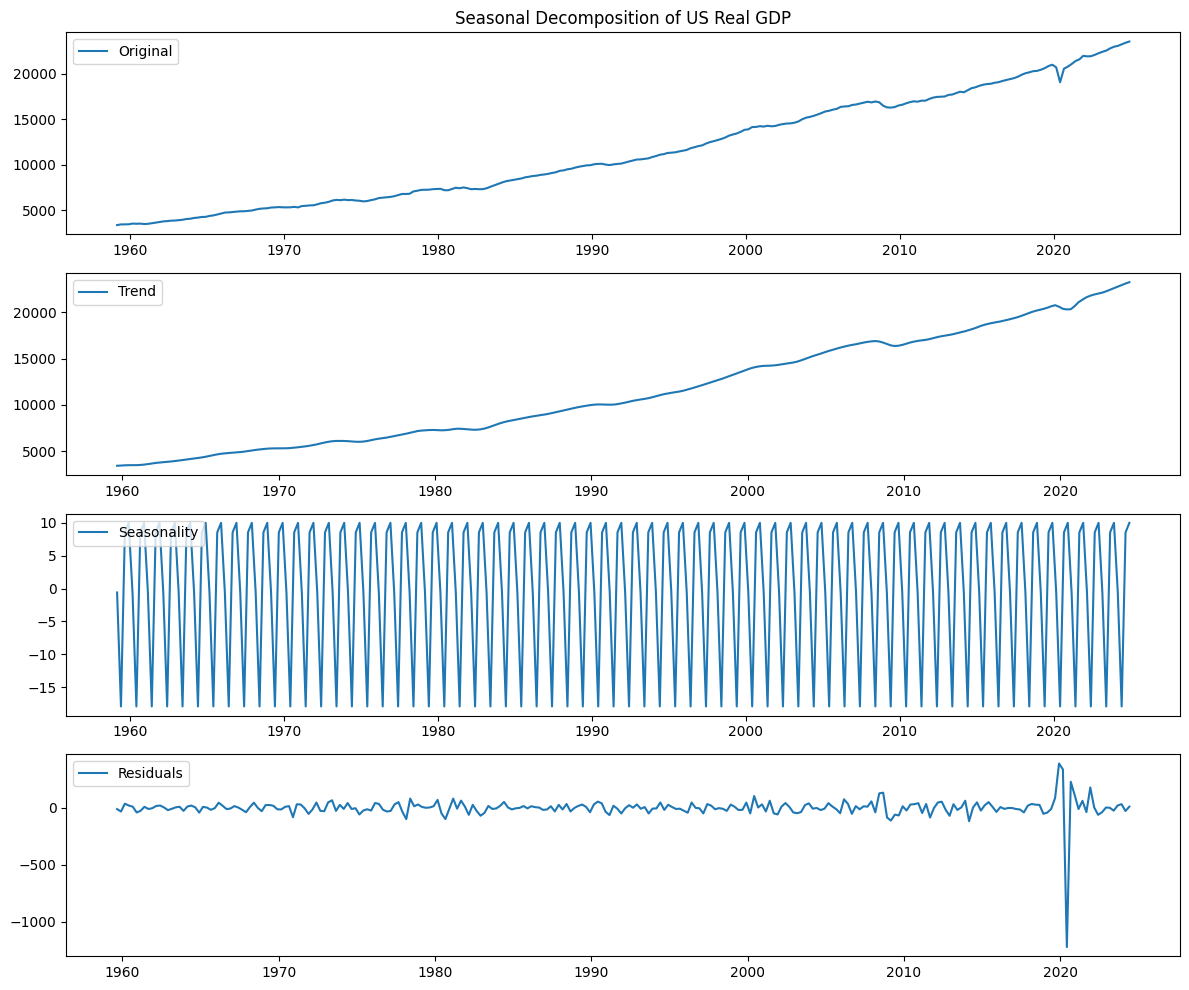

In [13]:


# Ensure GDP series is datetime-indexed
# Convert date column to datetime



qd_df = pd.read_csv("FRED_QD.csv")
gdp_series = qd_df[['sasdate', 'GDPC1']].copy()
gdp_series['sasdate'] = pd.to_datetime(gdp_series['sasdate'], errors='coerce')
gdp_series.dropna(subset=['sasdate'], inplace=True)
gdp_series.set_index('sasdate', inplace=True)

# Perform seasonal decomposition (assume quarterly frequency: freq=4)
decomposition = seasonal_decompose(gdp_series['GDPC1'], model='additive', period=4)

# Plot the components: Original, Trend, Seasonal, Residual
plt.figure(figsize=(12, 10))

plt.subplot(411)
plt.plot(gdp_series['GDPC1'], label='Original')
plt.legend(loc='upper left')
plt.title('Seasonal Decomposition of US Real GDP')

plt.subplot(412)
plt.plot(decomposition.trend, label='Trend')
plt.legend(loc='upper left')

plt.subplot(413)
plt.plot(decomposition.seasonal, label='Seasonality')
plt.legend(loc='upper left')

plt.subplot(414)
plt.plot(decomposition.resid, label='Residuals')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()


Figure of quarterly GDP change 

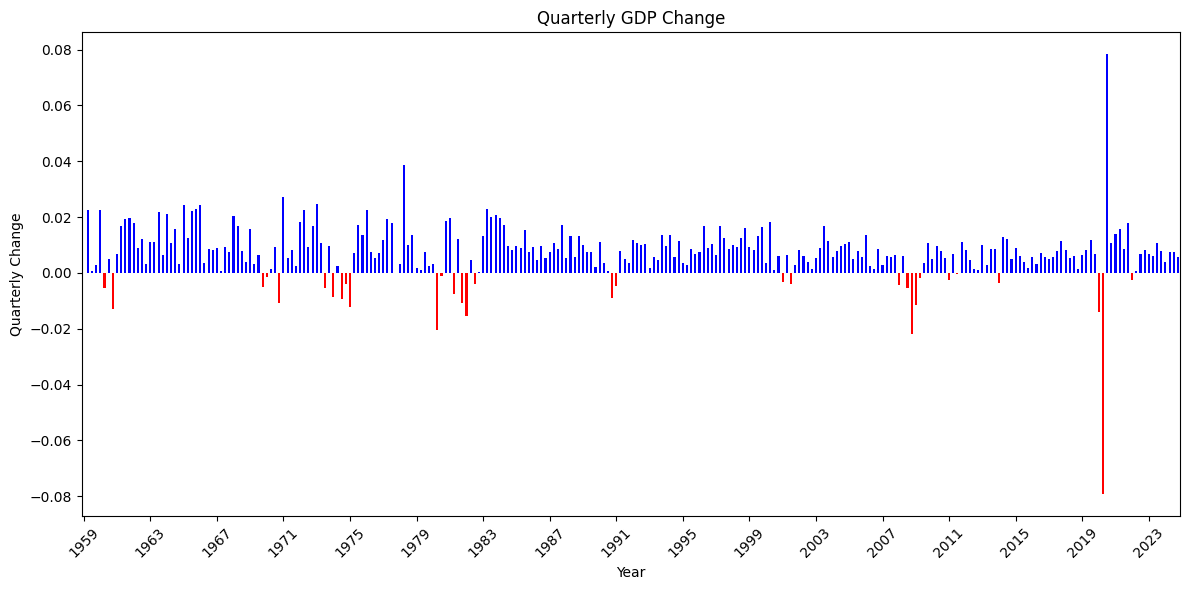

In [33]:
# Calculate quarterly GDP percentage change
gdp_series['GDP_Change'] = gdp_series['GDPC1'].pct_change()

# Plot the quarterly GDP change
plt.figure(figsize=(12, 6))
gdp_series['GDP_Change'].plot(kind='bar', color=gdp_series['GDP_Change'].apply(lambda x: 'red' if x < 0 else 'blue'))

# Customize the plot
plt.title('Quarterly GDP Change')
plt.xlabel('Year')
plt.ylabel('Quarterly Change')
plt.xticks(ticks=range(0, len(gdp_series), 16), labels=gdp_series.index[::16].year, rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Business cycle data
business_cycles = [
    {"peak": "", "trough": "1854-12-01"},
    {"peak": "1857-06-01", "trough": "1858-12-01"},
    {"peak": "1860-10-01", "trough": "1861-06-01"},
    {"peak": "1865-04-01", "trough": "1867-12-01"},
    {"peak": "1869-06-01", "trough": "1870-12-01"},
    {"peak": "1873-10-01", "trough": "1879-03-01"},
    {"peak": "1882-03-01", "trough": "1885-05-01"},
    {"peak": "1887-03-01", "trough": "1888-04-01"},
    {"peak": "1890-07-01", "trough": "1891-05-01"},
    {"peak": "1893-01-01", "trough": "1894-06-01"},
    {"peak": "1895-12-01", "trough": "1897-06-01"},
    {"peak": "1899-06-01", "trough": "1900-12-01"},
    {"peak": "1902-09-01", "trough": "1904-08-01"},
    {"peak": "1907-05-01", "trough": "1908-06-01"},
    {"peak": "1910-01-01", "trough": "1912-01-01"},
    {"peak": "1913-01-01", "trough": "1914-12-01"},
    {"peak": "1918-08-01", "trough": "1919-03-01"},
    {"peak": "1920-01-01", "trough": "1921-07-01"},
    {"peak": "1923-05-01", "trough": "1924-07-01"},
    {"peak": "1926-10-01", "trough": "1927-11-01"},
    {"peak": "1929-08-01", "trough": "1933-03-01"},
    {"peak": "1937-05-01", "trough": "1938-06-01"},
    {"peak": "1945-02-01", "trough": "1945-10-01"},
    {"peak": "1948-11-01", "trough": "1949-10-01"},
    {"peak": "1953-07-01", "trough": "1954-05-01"},
    {"peak": "1957-08-01", "trough": "1958-04-01"},
    {"peak": "1960-04-01", "trough": "1961-02-01"},
    {"peak": "1969-12-01", "trough": "1970-11-01"},
    {"peak": "1973-11-01", "trough": "1975-03-01"},
    {"peak": "1980-01-01", "trough": "1980-07-01"},
    {"peak": "1981-07-01", "trough": "1982-11-01"},
    {"peak": "1990-07-01", "trough": "1991-03-01"},
    {"peak": "2001-03-01", "trough": "2001-11-01"},
    {"peak": "2007-12-01", "trough": "2009-06-01"},
    {"peak": "2020-02-01", "trough": "2020-04-01"}
]

# Convert dates to datetime objects and filter out cycles before 1959
business_cycles = [
    {"peak": datetime.strptime(cycle["peak"], "%Y-%m-%d") if cycle["peak"] else None,
     "trough": datetime.strptime(cycle["trough"], "%Y-%m-%d") if cycle["trough"] else None}
    for cycle in business_cycles
    if (not cycle["trough"] or datetime.strptime(cycle["trough"], "%Y-%m-%d") >= datetime(1959, 1, 1))
]

# Create the plot
plt.figure(figsize=(12, 6))
for cycle in business_cycles:
    if cycle["peak"] and cycle["trough"]:
        plt.plot([cycle["peak"], cycle["trough"]], [1, 1], color='red', linewidth=2)
    elif cycle["trough"]:
        plt.scatter(cycle["trough"], 1, color='blue', label='Trough')

# Customize the plot
plt.title("US Business Cycle Peaks and Troughs")
plt.xlabel("Year")
plt.yticks([])
plt.gca().xaxis.set_major_locator(mdates.YearLocator(10))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

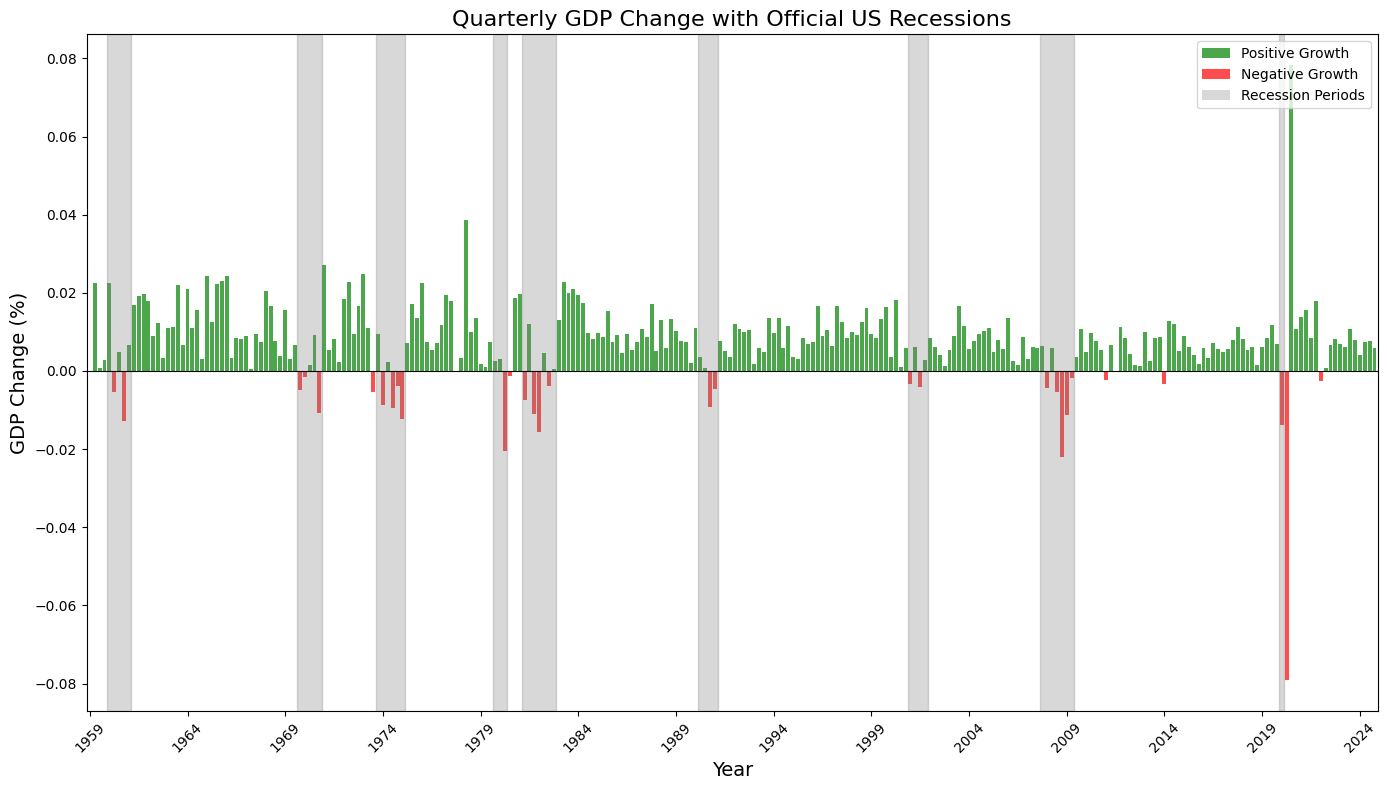

In [74]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

# Ensure we have the properly formatted GDP data
if 'GDP_Change' not in gdp_series.columns:
    gdp_series['GDP_Change'] = gdp_series['GDPC1'].pct_change()

# Define recession periods from NBER dates
recessions = [
    ('1960-04-01', '1961-02-01'),
    ('1969-12-01', '1970-11-01'),
    ('1973-11-01', '1975-03-01'),
    ('1980-01-01', '1980-07-01'),
    ('1981-07-01', '1982-11-01'),
    ('1990-07-01', '1991-03-01'),
    ('2001-03-01', '2001-11-01'),
    ('2007-12-01', '2009-06-01'),
    ('2020-02-01', '2020-04-01')
]

# Convert recession dates to datetime
recessions = [(pd.to_datetime(start), pd.to_datetime(end)) for start, end in recessions]

# Create the plot
fig, ax = plt.subplots(figsize=(14, 8))

# Plot GDP change
gdp_series['GDP_Change'].plot(kind='bar', ax=ax, color=gdp_series['GDP_Change'].apply(
    lambda x: 'red' if x < 0 else 'green'), width=0.8, alpha=0.7)

# Shade recession periods
for start, end in recessions:
    # Convert dates to positions in the DataFrame index
    try:
        start_idx = gdp_series.index.get_indexer([start], method='nearest')[0]
        end_idx = gdp_series.index.get_indexer([end], method='nearest')[0]
        
        # Add gray rectangle for the recession period
        ax.axvspan(start_idx-0.5, end_idx+0.5, color='gray', alpha=0.3)
    except:
        print(f"Could not shade recession period {start} to {end}")

# Add a horizontal line at y=0
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)

# Customize the plot
ax.set_title('Quarterly GDP Change with Official US Recessions', fontsize=16)
ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('GDP Change (%)', fontsize=14)

# Set x-axis ticks to be every 20 quarters (5 years)
step = 20
tick_positions = list(range(0, len(gdp_series), step))
ax.set_xticks(tick_positions)
ax.set_xticklabels([gdp_series.index[i].strftime('%Y') for i in tick_positions], rotation=45)

# Create legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='green', alpha=0.7, label='Positive Growth'),
    Patch(facecolor='red', alpha=0.7, label='Negative Growth'),
    Patch(facecolor='gray', alpha=0.3, label='Recession Periods')
]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

Which features are highly correlated with GDP?

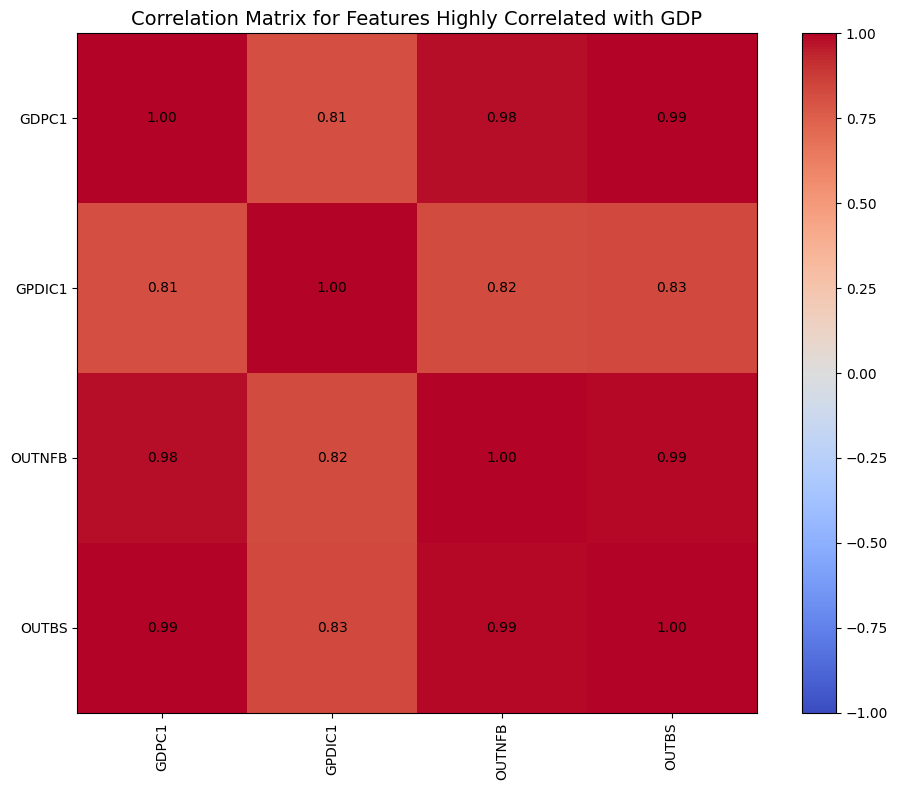

Features with high correlation (abs > 0.90) with GDP:
GPDIC1    0.812371
OUTNFB    0.980791
OUTBS     0.993620
Name: GDPC1, dtype: float64


In [13]:
# Load train data which returns a tuple of DataFrames
data = load_train_data()
# Access the correct DataFrame (second element of the tuple that contains GDPC1)
gdp_data = data[1]  # Using the second DataFrame which contains GDPC1
# Calculate correlation with GDP
correlation_with_gdp = gdp_data.corr()['GDPC1'].sort_values()

# Filter for high correlations (absolute value >0.90) excluding GDPC1 itself
high_correlations_positive = correlation_with_gdp[(correlation_with_gdp > 0.80) & (correlation_with_gdp < 1.0)]
high_correlations_negative = correlation_with_gdp[correlation_with_gdp < -0.80]
high_correlations = pd.concat([high_correlations_negative, high_correlations_positive])

# Create a correlation matrix for these highly correlated features
if len(high_correlations) > 0:
    highly_correlated_features = list(high_correlations.index)
    # Add GDPC1 to the list
    features_to_include = ['GDPC1'] + highly_correlated_features
    
    # Create correlation matrix
    high_corr_matrix = gdp_data[features_to_include].corr()
    
    # Plot the correlation matrix
    plt.figure(figsize=(10, 8))
    plt.title('Correlation Matrix for Features Highly Correlated with GDP', fontsize=14)
    heatmap = plt.imshow(high_corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
    plt.colorbar(heatmap)
    
    # Add correlation values
    for i in range(len(features_to_include)):
        for j in range(len(features_to_include)):
            text = plt.text(j, i, f"{high_corr_matrix.iloc[i, j]:.2f}",
                           ha="center", va="center", color="black")
    
    plt.xticks(range(len(features_to_include)), features_to_include, rotation=90)
    plt.yticks(range(len(features_to_include)), features_to_include)
    plt.tight_layout()
    plt.show()
    
    print("Features with high correlation (abs > 0.90) with GDP:")
    print(high_correlations)
else:
    print("No features found with correlation magnitude > 0.90")